# Notebook 01 — Diagnóstico e Preparação dos Dados

**Projeto:** Análise da Logística Portuária Brasileira — ANTAQ  
**Fonte:** ANTAQ Open Data 2023–2025, CPPI World Bank  
**Objetivo:** Inventariar, avaliar a qualidade e construir os datasets limpos para os notebooks de análise.

---

## Estrutura deste notebook

1. Setup e inventário dos arquivos  
2. Dataset de Atracações 2023–2025  
3. Indicadores Operacionais 2025 (Tempos, Paralisações, Taxa de Ocupação)  
4. Datasets de referência (Terminais de Contêineres, CPPI)  
5. Construção do dataset principal (Atracações + Tempos — terminais de contêineres)  
6. Sumário de qualidade e exportação  

> **Nota sobre os arquivos de Carga:** Os arquivos `2023_Carga.csv`, `2024_Carga.csv` e `2025_Carga.csv`  
> atingem exatamente 1.048.575 linhas — o limite de linhas do Excel — indicando truncagem na exportação.  
> Análises de volume de carga (tonelagem, TEU por mercadoria) estão excluídas deste projeto até que  
> os arquivos sejam re-exportados diretamente da plataforma ANTAQ sem uso de Excel.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT       = os.path.abspath('..')
DATA       = os.path.join(ROOT, 'data')
OUTPUTS    = os.path.join(ROOT, 'outputs')
PROC       = os.path.join(OUTPUTS, 'processed_data')
FIGS       = os.path.join(OUTPUTS, 'figures')
os.makedirs(PROC, exist_ok=True)
os.makedirs(FIGS, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
})
PALETTE = ['#1d4e89', '#2980b9', '#e74c3c', '#e67e22', '#27ae60', '#8e44ad']

print("Setup concluído.")
print(f"ROOT: {ROOT}")

Setup concluído.
ROOT: /sessions/kind-brave-meitner/mnt/ANTAQ_Projeto - Copia


## 2. Inventário dos Arquivos

In [2]:
files_info = []

manifest = {
    '01_Cadastros': [
        'Relatorio_Instalacao_Portuaria.csv',
        'Relatorio_Berco.csv',
        'Relatorio_Mercadoria.csv',
        'Vessels_Master.csv',
    ],
    '02_Operacoes': [
        '2023_Atracacao.csv', '2024_Atracacao.csv', '2025_Atracacao.csv',
        '2023_Carga.csv',     '2024_Carga.csv',     '2025_Carga.csv',
        'KPIs_Terminais_2025.csv',
        'Terminais_Conteiner_Brasil.csv',
        'Vessels_Master_Enriched.csv',
    ],
    '03_Indicadores': [
        '2025_Tempos_Atracacao.csv',
        '2025_Tempos_Atracacao_Paralisacao.csv',
        '2025_Taxa_Ocupacao.csv',
        '2025_Taxa_Ocupacao_Com_Carga.csv',
        '2025_Taxa_Ocupacao_TO_Atracacao.csv',
    ],
    '04_Benchmark': [
        'CPPI_2020_2024.csv',
    ],
    '02_Operacoes (extras)': [
        'CPPI_Brasil_2023.csv',
    ],
}

EXCEL_LIMIT = 1_048_575  # limite de linhas do Excel (excl. header)

for folder, flist in manifest.items():
    for fname in flist:
        fpath = os.path.join(DATA, folder, fname)
        if os.path.exists(fpath):
            size_mb = os.path.getsize(fpath) / 1_048_576
            with open(fpath, 'rb') as f:
                nlines = sum(1 for _ in f) - 1   # descontar header
            truncated = '⚠️ TRUNCADO' if nlines >= EXCEL_LIMIT else '✅'
            files_info.append({
                'pasta': folder,
                'arquivo': fname,
                'tamanho_mb': round(size_mb, 1),
                'linhas_dados': f'{nlines:,}',
                'status': truncated,
            })
        else:
            files_info.append({'pasta': folder, 'arquivo': fname,
                                'tamanho_mb': '-', 'linhas_dados': '-', 'status': '❌ AUSENTE'})

df_inv = pd.DataFrame(files_info)
print(df_inv.to_string(index=False))

                pasta                               arquivo tamanho_mb linhas_dados      status
         01_Cadastros    Relatorio_Instalacao_Portuaria.csv        0.1          735           ✅
         01_Cadastros                   Relatorio_Berco.csv        0.1          875           ✅
         01_Cadastros              Relatorio_Mercadoria.csv        0.3        1,402           ✅
         01_Cadastros                    Vessels_Master.csv        0.1        1,378           ✅
         02_Operacoes                    2023_Atracacao.csv       30.7       93,918           ✅
         02_Operacoes                    2024_Atracacao.csv       35.0      106,834           ✅
         02_Operacoes                    2025_Atracacao.csv       36.7      116,098           ✅
         02_Operacoes                        2023_Carga.csv      182.5    1,048,575 ⚠️ TRUNCADO
         02_Operacoes                        2024_Carga.csv      184.2    1,048,575 ⚠️ TRUNCADO
         02_Operacoes                   

## 3. Dataset de Atracações 2023–2025

Base operacional central do projeto. Contém cada evento de atracação com identificação do terminal,  
porto, UF, tipo de navegação, tipo de operação e timestamps de chegada / atracação / operação / desatracação.

In [3]:
DATE_COLS = ['Data Atracação', 'Data Chegada', 'Data Desatracação',
             'Data Início Operação', 'Data Término Operação']

frames = []
for ano in [2023, 2024, 2025]:
    fpath = os.path.join(DATA, '02_Operacoes', f'{ano}_Atracacao.csv')
    df = pd.read_csv(fpath, sep=';', encoding='utf-8-sig', low_memory=False)
    for col in DATE_COLS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    frames.append(df)
    print(f"{ano}: {len(df):>7,} registros | {df['Tipo de Navegação da Atracação'].value_counts().to_dict()}")

df_atrac = pd.concat(frames, ignore_index=True)
print(f"\nTotal consolidado: {len(df_atrac):,} registros")

2023:  93,918 registros | {'Interior': 46113, 'Longo Curso': 22447, 'Cabotagem': 15919, 'Apoio Marítimo': 5345, 'Apoio Portuário': 3970}


2024: 106,834 registros | {'Interior': 50371, 'Longo Curso': 21751, 'Cabotagem': 21238, 'Apoio Marítimo': 8397, 'Apoio Portuário': 4979}


2025: 116,098 registros | {'Interior': 54127, 'Longo Curso': 22746, 'Cabotagem': 21183, 'Apoio Marítimo': 11798, 'Apoio Portuário': 6238}

Total consolidado: 316,850 registros


### 3.1 Qualidade — Atracações

In [4]:
# Campos-chave e seus missings
quality_cols = ['IDAtracacao', 'Porto Atracação', 'Terminal', 'UF', 'Região Geográfica',
                'Tipo de Navegação da Atracação', 'Tipo de Operação',
                'Data Atracação', 'Data Chegada', 'Data Desatracação',
                'Data Início Operação', 'Data Término Operação', 'Nº do IMO']

q = pd.DataFrame({
    'campo': quality_cols,
    'missings': [df_atrac[c].isna().sum() for c in quality_cols],
    'pct_missing': [f"{df_atrac[c].isna().mean()*100:.1f}%" for c in quality_cols],
})
print(q.to_string(index=False))

print(f"\n⚠️  IMO ausente em {df_atrac['Nº do IMO'].isna().mean()*100:.1f}% dos registros.")
print("    Isso limita análises por perfil técnico de navio.")

                         campo  missings pct_missing
                   IDAtracacao         0        0.0%
               Porto Atracação       228        0.1%
                      Terminal       229        0.1%
                            UF       229        0.1%
             Região Geográfica       229        0.1%
Tipo de Navegação da Atracação       228        0.1%
              Tipo de Operação       228        0.1%
                Data Atracação       228        0.1%
                  Data Chegada       228        0.1%
             Data Desatracação         0        0.0%
          Data Início Operação     19579        6.2%
         Data Término Operação     19556        6.2%
                     Nº do IMO    154867       48.9%

⚠️  IMO ausente em 48.9% dos registros.
    Isso limita análises por perfil técnico de navio.


### 3.2 Distribuição por Tipo de Navegação e Ano

Tipo de Navegação da Atracação  Apoio Marítimo  Apoio Portuário  Cabotagem  Interior  Longo Curso   TOTAL
Ano                                                                                                      
2023                                      5345             3970      15919     46113        22447   93794
2024                                      8397             4979      21238     50371        21751  106736
2025                                     11798             6238      21183     54127        22746  116092


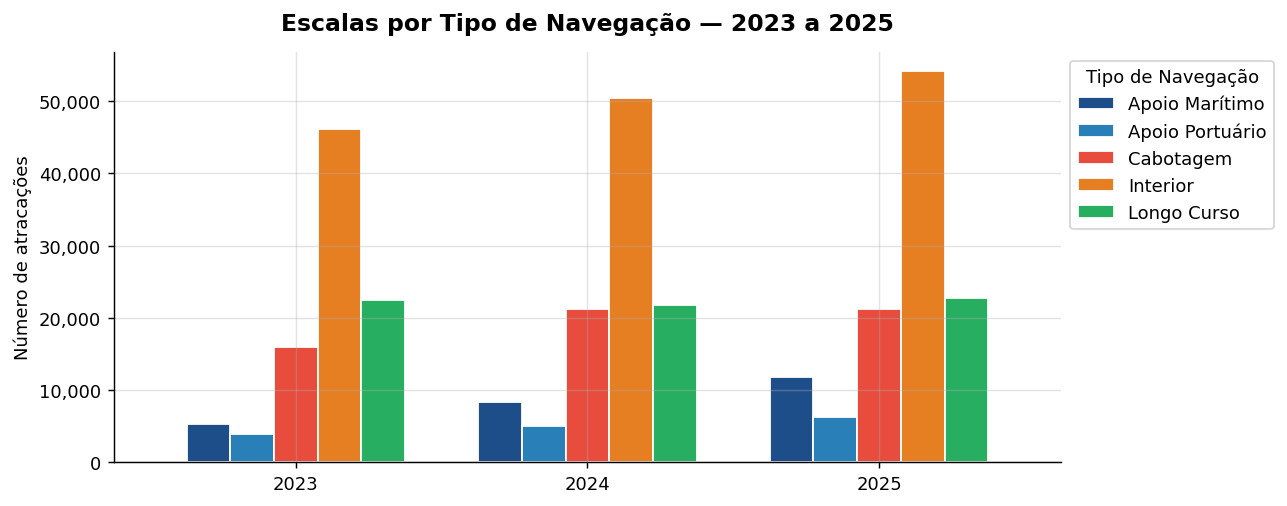

Figura salva.


In [5]:
# Tabela cruzada: ano x tipo de navegação
tab = df_atrac.groupby(['Ano', 'Tipo de Navegação da Atracação']).size().unstack(fill_value=0)
tab['TOTAL'] = tab.sum(axis=1)
print(tab.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(10, 4))
tab.drop('TOTAL', axis=1).plot(kind='bar', ax=ax, color=PALETTE[:5], edgecolor='white', width=0.75)
ax.set_title('Escalas por Tipo de Navegação — 2023 a 2025', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Número de atracações')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Tipo de Navegação', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'nb01_escalas_tipo_navegacao.png'), bbox_inches='tight')
plt.show()
print("Figura salva.")

## 4. Indicadores Operacionais 2025

### 4.1 Tempos de Atracação

Cada linha corresponde a um evento de atracação (IDAtracacao) com os seguintes campos de tempo (em horas):

| Campo               | Significado                                                |
|---------------------|------------------------------------------------------------|
| TEsperaAtracacao    | Tempo fundeado aguardando berço disponível                 |
| TEsperaInicioOp     | Tempo atracado antes de iniciar operação                   |
| TOperacao           | Tempo efetivo de operação                                  |
| TEsperaDesatracacao | Tempo após fim de operação até desatracação                |
| TAtracado           | Total atracado = TEsperaInicioOp + TOperacao + TEsperaDesatracacao |
| TEstadia            | Total = TEsperaAtracacao + TAtracado                       |

In [6]:
df_tempos = pd.read_csv(
    os.path.join(DATA, '03_Indicadores', '2025_Tempos_Atracacao.csv'),
    sep=';', encoding='utf-8-sig'
)

# Converter decimais (vírgula → ponto) e tratar "Valor Discrepante"
TIME_COLS = ['TEsperaAtracacao', 'TEsperaInicioOp', 'TOperacao',
             'TEsperaDesatracacao', 'TAtracado', 'TEstadia']

for col in TIME_COLS:
    df_tempos[col] = (df_tempos[col]
                      .astype(str)
                      .str.replace(',', '.', regex=False)
                      .replace('Valor Discrepante', np.nan))
    df_tempos[col] = pd.to_numeric(df_tempos[col], errors='coerce')

# Diagnóstico de discrepantes e negativos
print("=== Qualidade — Tempos ===")
for col in TIME_COLS:
    n_nan  = df_tempos[col].isna().sum()
    n_neg  = (df_tempos[col] < 0).sum()
    n_disc = (df_tempos[col] > 720).sum()  # > 30 dias = suspeito
    print(f"  {col:<22} | NaN: {n_nan:>6,} | Negativos: {n_neg:>5,} | >30 dias: {n_disc:>5,}")

# Remover negativos e extremos (>30 dias) — manter flag para transparência
mask_valid = (
    df_tempos[TIME_COLS].ge(0).all(axis=1) &
    df_tempos['TEstadia'].le(720) &
    df_tempos[TIME_COLS].notna().all(axis=1)
)
df_tempos_clean = df_tempos[mask_valid].copy()
print(f"\nRegistros válidos: {len(df_tempos_clean):,} de {len(df_tempos):,} ({len(df_tempos_clean)/len(df_tempos)*100:.1f}%)")

=== Qualidade — Tempos ===
  TEsperaAtracacao       | NaN:  4,222 | Negativos:     0 | >30 dias:   244
  TEsperaInicioOp        | NaN:  9,123 | Negativos:     0 | >30 dias:    17
  TOperacao              | NaN:  9,197 | Negativos:     0 | >30 dias:     3
  TEsperaDesatracacao    | NaN:  7,914 | Negativos:     0 | >30 dias:     0
  TAtracado              | NaN:  2,172 | Negativos:     0 | >30 dias:    21
  TEstadia               | NaN:  2,245 | Negativos:     0 | >30 dias:   427

Registros válidos: 99,445 de 116,098 (85.7%)


### 4.2 Paralisações — Causas de Tempo Não-Operacional

In [7]:
df_par = pd.read_csv(
    os.path.join(DATA, '03_Indicadores', '2025_Tempos_Atracacao_Paralisacao.csv'),
    sep=';', encoding='utf-8-sig'
)
df_par['DTInicio']  = pd.to_datetime(df_par['DTInicio'],  errors='coerce')
df_par['DTTermino'] = pd.to_datetime(df_par['DTTermino'], errors='coerce')
df_par['duracao_h'] = (df_par['DTTermino'] - df_par['DTInicio']).dt.total_seconds() / 3600

# Agrupar por causa
par_cat = (df_par.groupby('DescricaoTempoDesconto')
               .agg(eventos=('IDAtracacao','count'), duracao_total_h=('duracao_h','sum'))
               .sort_values('eventos', ascending=False)
               .reset_index())
par_cat['pct_eventos'] = (par_cat['eventos'] / par_cat['eventos'].sum() * 100).round(1)
par_cat['duracao_media_h'] = (par_cat['duracao_total_h'] / par_cat['eventos']).round(2)

print(par_cat[['DescricaoTempoDesconto','eventos','pct_eventos','duracao_media_h']].to_string(index=False))

                                             DescricaoTempoDesconto  eventos  pct_eventos  duracao_media_h
                                                   Aguardando carga    44709         19.6             0.17
               Chuva e/ou outras condições climáticas desfavoráveis    29428         12.9             2.24
                                                   Mudança de porão    26867         11.8             0.28
                                   Aguardando transporte rodoviário    25286         11.1             0.34
                                                     Troca de turno    20689          9.1             0.35
             Quebra de equipamento do Porto, devidamente comprovada    12214          5.4             0.36
Quebra de equipamento do Operador Portuário, devidamente comprovada    10321          4.5             0.88
                    Maré para embarcações com restrição de operação     7869          3.4             1.41
                                     

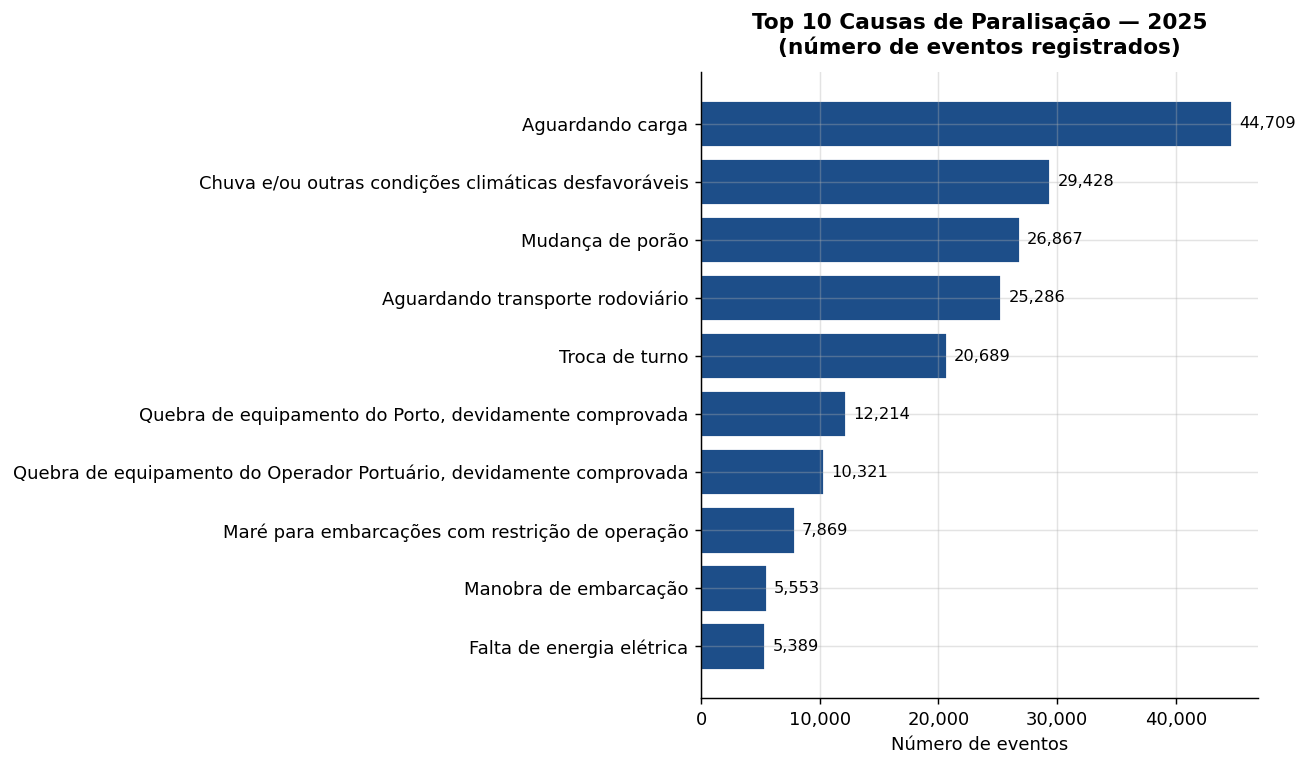


⚠️  'Aguardando transporte rodoviário' aparece como 4ª maior causa de paralisação.
    25.286 eventos de paralisação por falta de caminhões — problema de conectividade hinterland.


In [8]:
# Visualização: Top 10 causas de paralisação por número de eventos
top10 = par_cat.head(10).sort_values('eventos')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['DescricaoTempoDesconto'], top10['eventos'],
               color=PALETTE[0], edgecolor='white')
ax.bar_label(bars, labels=[f"{v:,}" for v in top10['eventos']],
             padding=4, fontsize=9)
ax.set_title('Top 10 Causas de Paralisação — 2025\n(número de eventos registrados)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Número de eventos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'nb01_causas_paralisacao.png'), bbox_inches='tight')
plt.show()
print("\n⚠️  'Aguardando transporte rodoviário' aparece como 4ª maior causa de paralisação.")
print("    25.286 eventos de paralisação por falta de caminhões — problema de conectividade hinterland.")

## 5. Datasets de Referência

In [9]:
# ── Terminais de Contêineres ──────────────────────────────────────────────
df_term = pd.read_csv(
    os.path.join(DATA, '02_Operacoes', 'Terminais_Conteiner_Brasil.csv'),
    encoding='utf-8-sig'
)
print(f"Terminais de contêineres identificados: {len(df_term)}")
print(df_term.to_string(index=False))

Terminais de contêineres identificados: 12
              operador  capacidade_teu_ano  num_bercos  comprimento_cais_m  profundidade_m  num_guindastes                  cidade uf
         Santos Brasil             1200000           5                1260            15.0              14                  Santos SP
                   BTP             1100000           3                 900            16.0               9                  Santos SP
       DP World Santos              500000           2                 640            13.5               6                  Santos SP
         TCP Paranaguá             1200000           4                 920            14.5              10               Paranaguá PR
          Porto Itapoá              900000           2                 700            16.0               6                  Itapoá SC
             Portonave              750000           3                 780            14.5               8              Navegantes SC
      Tecon Rio Gra

In [10]:
# ── CPPI Brasil 2023 ─────────────────────────────────────────────────────
df_cppi_br = pd.read_csv(
    os.path.join(DATA, '02_Operacoes', 'CPPI_Brasil_2023.csv'),
    encoding='utf-8-sig'
)
print("CPPI Brasil 2023:")
print(df_cppi_br.to_string(index=False))

CPPI Brasil 2023:
         porto  cppi_rank_2023  cppi_score  benchmark_horas_escala
        Santos             122         2.8                    28.4
     Paranaguá             145         2.5                    31.2
        Itapoá              98         3.1                    24.1
    Navegantes             134         2.6                    29.8
    Rio Grande             156         2.3                    33.5
         Suape             167         2.1                    36.2
         Pecém             178         1.9                    38.1
Rio de Janeiro             189         1.7                    41.3


In [11]:
# ── KPIs Terminais 2025 (preprocessado) ──────────────────────────────────
df_kpi = pd.read_csv(
    os.path.join(DATA, '02_Operacoes', 'KPIs_Terminais_2025.csv'),
    encoding='utf-8-sig'
)
# Corrigir encoding
df_kpi['Terminal'] = (df_kpi['Terminal']
                      .str.replace('Ã¡', 'á').str.replace('Ã£', 'ã')
                      .str.replace('Ã©', 'é').str.replace('Ã³', 'ó')
                      .str.replace('Ã ', 'à').str.replace('Ã©', 'é'))
print("KPIs Terminais 2025:")
print(df_kpi.to_string(index=False))

KPIs Terminais 2025:
                                      Terminal  n_escalas  teu_medio  prancha_media  espera_media_h  operacao_media_h  estadia_media_h  pct_paralisacao
                                   TECON Suape        544     1283.4          220.3             8.3              18.7             31.2             20.3
Portonave - Terminais Portuários de Navegantes        480     2153.2          200.8            26.2              10.1             39.7             24.7
    Cais da Santos Brasil (SSZ 16) - Privativo        988     2420.7          123.3            26.6              19.8             52.8             27.5
              Cais da BTP (SSZ 41) - Privativo        728     2234.4          114.7            30.1              20.1             57.0             26.0
                                           TCP        736     1792.2          110.0            34.0              17.5             54.6             16.5
                               DP World Santos        555     2057.

## 6. Construção do Dataset Principal para Análise

Filtragem e junção dos datasets para o Notebook 02 (Eficiência de Terminais de Contêineres).

**Critério de seleção:**
- Tipo de Navegação: **Longo Curso** (navegação internacional — base do benchmarking CPPI)
- Terminal: presença na lista dos 12 terminais de contêineres identificados
- Ano: 2023, 2024, 2025
- Join com Tempos de Atracação 2025 (único ano disponível para indicadores)

In [12]:
# Mapeamento de nomes de terminal (Atracação → padrão do projeto)
TERMINAL_MAP = {
    'Cais da Santos Brasil (SSZ 16) - Privativo': 'Santos Brasil',
    'Cais da BTP (SSZ 41) - Privativo'          : 'BTP',
    'DP World Santos'                            : 'DP World Santos',
    'TCP'                                        : 'TCP Paranaguá',
    'Porto Itapoá Terminais Portuários'          : 'Porto Itapoá',
    'Portonave - Terminais Portuários de Navegantes': 'Portonave',
    'Cais Tecon Rio Grande S.A.'                 : 'Tecon Rio Grande',
    'TECON Suape'                                : 'Tecon Suape',
    'Terminal Portuário do Pecém'                : 'CIPP Pecém',
    'Multi-Rio'                                  : 'Multi-Rio',
    'ICTSI'                                      : 'ICTSI Rio',
    'Terminal Vila do Conde'                     : 'Terminal Vila do Conde',
    'Tecon Sepetiba'                             : 'Tecon Sepetiba',
}

# Filtrar Longo Curso nos terminais mapeados
df_lc = df_atrac[
    (df_atrac['Tipo de Navegação da Atracação'] == 'Longo Curso') &
    (df_atrac['Terminal'].isin(TERMINAL_MAP.keys()))
].copy()
df_lc['terminal_std'] = df_lc['Terminal'].map(TERMINAL_MAP)

print(f"Longo Curso — terminais de contêineres (2023-2025): {len(df_lc):,} escalas")
print("\nEscalas por terminal e ano:")
print(df_lc.groupby(['terminal_std', 'Ano']).size().unstack(fill_value=0).to_string())

Longo Curso — terminais de contêineres (2023-2025): 16,205 escalas

Escalas por terminal e ano:
Ano                     2023  2024  2025
terminal_std                            
BTP                      649   682   675
CIPP Pecém               290   275   385
DP World Santos          591   493   455
ICTSI Rio                205   279   334
Multi-Rio                378   359   367
Porto Itapoá             570   637   692
Portonave                534   345   334
Santos Brasil            685   684   728
TCP Paranaguá            776   764   716
Tecon Rio Grande         305   297   408
Tecon Sepetiba           136   204   217
Tecon Suape              102   130   113
Terminal Vila do Conde   132   131   148


In [13]:
# Join com Tempos 2025 (só 2025 disponível para indicadores)
df_lc_2025 = df_lc[df_lc['Ano'] == 2025].copy()
df_main = df_lc_2025.merge(df_tempos_clean, on='IDAtracacao', how='inner')

print(f"Dataset principal (2025, contêineres, Longo Curso + Tempos): {len(df_main):,} registros")
print(f"Cobertura: {len(df_main)/len(df_lc_2025)*100:.1f}% das escalas 2025 têm tempos válidos")
print("\nRegistros por terminal:")
print(df_main['terminal_std'].value_counts().to_string())

Dataset principal (2025, contêineres, Longo Curso + Tempos): 5,380 registros
Cobertura: 96.6% das escalas 2025 têm tempos válidos

Registros por terminal:
terminal_std
Santos Brasil             727
TCP Paranaguá             705
BTP                       668
Porto Itapoá              581
DP World Santos           448
Tecon Rio Grande          405
Multi-Rio                 365
CIPP Pecém                360
ICTSI Rio                 333
Portonave                 325
Tecon Sepetiba            208
Terminal Vila do Conde    142
Tecon Suape               113


## 7. Sumário de Qualidade — O que está disponível

In [14]:
print("=" * 65)
print("SUMÁRIO DE DADOS — PROJETO ANTAQ")
print("=" * 65)

summary = [
    ("✅", "Atracações 2023",       f"{len(frames[0]):,} registros"),
    ("✅", "Atracações 2024",       f"{len(frames[1]):,} registros"),
    ("✅", "Atracações 2025",       f"{len(frames[2]):,} registros"),
    ("✅", "Tempos Atracação 2025", f"{len(df_tempos_clean):,} válidos de {len(df_tempos):,}"),
    ("✅", "Paralisações 2025",     f"{len(df_par):,} eventos | {len(par_cat)} categorias"),
    ("✅", "Taxa de Ocupação 2025", "325.945 registros diários por berço"),
    ("✅", "Terminais Contêineres", f"{len(df_term)} terminais | infraestrutura completa"),
    ("✅", "CPPI Brasil 2023",      f"{len(df_cppi_br)} portos com ranking e score"),
    ("✅", "CPPI Global 2020–2024", "398 portos | benchmarking internacional"),
    ("✅", "Dataset principal NB02",f"{len(df_main):,} escalas | Longo Curso + Tempos 2025"),
    ("⚠️", "Carga 2023/2024/2025", "TRUNCADO no limite Excel — excluído das análises"),
    ("⚠️", "Tempos 2023/2024",     "AUSENTES — séries históricas de indicadores indisponíveis"),
    ("⚠️", "IMO nos Atracações",   "49% ausente — análise por tipo de navio limitada"),
    ("⚠️", "Vessels_Master_Enriched","vessel_type 100% vazio — scraping incompleto"),
]

for status, dataset, obs in summary:
    print(f"  {status}  {dataset:<35} {obs}")

print("=" * 65)

SUMÁRIO DE DADOS — PROJETO ANTAQ
  ✅  Atracações 2023                     93,918 registros
  ✅  Atracações 2024                     106,834 registros
  ✅  Atracações 2025                     116,098 registros
  ✅  Tempos Atracação 2025               99,445 válidos de 116,098
  ✅  Paralisações 2025                   228,249 eventos | 29 categorias
  ✅  Taxa de Ocupação 2025               325.945 registros diários por berço
  ✅  Terminais Contêineres               12 terminais | infraestrutura completa
  ✅  CPPI Brasil 2023                    8 portos com ranking e score
  ✅  CPPI Global 2020–2024               398 portos | benchmarking internacional
  ✅  Dataset principal NB02              5,380 escalas | Longo Curso + Tempos 2025
  ⚠️  Carga 2023/2024/2025                TRUNCADO no limite Excel — excluído das análises
  ⚠️  Tempos 2023/2024                    AUSENTES — séries históricas de indicadores indisponíveis
  ⚠️  IMO nos Atracações                  49% ausente — análise por t

## 8. Exportação dos Datasets Processados

In [15]:
# Salvar datasets para uso nos notebooks seguintes
df_atrac.to_parquet(os.path.join(PROC, 'atracacao_2023_2025.parquet'), index=False)
df_lc.to_parquet(os.path.join(PROC, 'atracacao_lc_conteiner_2023_2025.parquet'), index=False)
df_main.to_parquet(os.path.join(PROC, 'dataset_principal_nb02.parquet'), index=False)
df_tempos_clean.to_parquet(os.path.join(PROC, 'tempos_2025_clean.parquet'), index=False)
df_par.to_csv(os.path.join(PROC, 'paralisacoes_2025_clean.csv'), index=False)
df_term.to_csv(os.path.join(PROC, 'terminais_conteiner_ref.csv'), index=False)
df_kpi.to_csv(os.path.join(PROC, 'kpis_terminais_2025.csv'), index=False)
df_cppi_br.to_csv(os.path.join(PROC, 'cppi_brasil_2023.csv'), index=False)

print("Arquivos exportados para outputs/processed_data/:")
for f in sorted(os.listdir(PROC)):
    fpath = os.path.join(PROC, f)
    size = os.path.getsize(fpath) / 1_048_576
    print(f"  {f:<50} {size:.1f} MB")

print("\n✅ Notebook 01 concluído. Dados prontos para Notebook 02.")

Arquivos exportados para outputs/processed_data/:
  atracacao_2023_2025.parquet                        15.8 MB
  atracacao_lc_conteiner_2023_2025.parquet           1.0 MB
  cppi_brasil_2023.csv                               0.0 MB
  dataset_principal_nb02.parquet                     0.4 MB
  kpis_terminais_2025.csv                            0.0 MB
  paralisacoes_2025_clean.csv                        22.2 MB
  tempos_2025_clean.parquet                          1.6 MB
  terminais_conteiner_ref.csv                        0.0 MB

✅ Notebook 01 concluído. Dados prontos para Notebook 02.
